# Hotel Cancellation — Decision Tree Model

Loads the `X`/`Y` train/test splits from `feature_prep.ipynb`, carves a stratified validation set out of train, sets a majority-class baseline, then trains and tunes a decision tree to predict `is_canceled`. The suspected-leaky `deposit_type_Non Refund` column is held out of the headline model and added back at the end to measure its effect. Per the milestone plan, models are judged on ROC-AUC and PR-AUC.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

PROCESSED_DIR = "../data/processed"

## 2. Load Processed Data

Trees split one feature at a time, so scaling doesn't matter to them. We reuse the scaled `X` files from `feature_prep.ipynb` anyway; that way every model trains on identical inputs.

In [2]:
X_train_full = pd.read_csv(f"{PROCESSED_DIR}/X_train.csv")
X_test = pd.read_csv(f"{PROCESSED_DIR}/X_test.csv")
Y_train_full = pd.read_csv(f"{PROCESSED_DIR}/Y_train.csv")["is_canceled"]
Y_test = pd.read_csv(f"{PROCESSED_DIR}/Y_test.csv")["is_canceled"]

print("X_train_full shape:", X_train_full.shape, "  Y_train_full shape:", Y_train_full.shape)
print("X_test shape:", X_test.shape, "  Y_test shape:", Y_test.shape)

X_train_full shape: (95368, 42)   Y_train_full shape: (95368,)
X_test shape: (23840, 42)   Y_test shape: (23840,)


## 3. Train / Validation Split

Carve a stratified validation set out of train for tuning. Test stays untouched until the final evaluation.

In [3]:
X_train_mini, X_val, Y_train_mini, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.2, random_state=1234, stratify=Y_train_full)

print("X_train_mini shape:", X_train_mini.shape)
print("X_val shape:", X_val.shape)
print("Cancel rate train:", round(Y_train_mini.mean(), 4))
print("Cancel rate val:", round(Y_val.mean(), 4))
print("Cancel rate test:", round(Y_test.mean(), 4))

X_train_mini shape: (76294, 42)
X_val shape: (19074, 42)
Cancel rate train: 0.3708
Cancel rate val: 0.3708
Cancel rate test: 0.3708


All three splits land at the same 37.1% cancel rate, so the stratification did its job.

## 4. Majority Baseline

The "stupid" baseline: predict stayed for everything.

In [4]:
# Predicting 0 (stayed) for every booking
majority_accuracy_val = np.sum(Y_val == 0) / len(Y_val)
majority_accuracy_test = np.sum(Y_test == 0) / len(Y_test)

print("Majority baseline accuracy (val):", round(majority_accuracy_val, 4))
print("Majority baseline accuracy (test):", round(majority_accuracy_test, 4))

Majority baseline accuracy (val): 0.6292
Majority baseline accuracy (test): 0.6292


The baseline scores 62.9% accuracy without catching a single cancellation, which is exactly why accuracy is the wrong metric here. The real floor to beat is PR-AUC 0.371 (the cancel rate) and ROC-AUC 0.5.

## 5. Baseline Decision Tree

We hold `deposit_type_Non Refund` out of the headline model; its 99.4% cancel rate in the EDA looks like leakage, a feature that encodes the outcome rather than predicting it. It comes back in section 8 so we can measure what it's actually worth. First, an unconstrained tree to see how bad the overfitting gets.

In [5]:
# Hold out the suspected-leaky deposit column (added back in section 8)
leaky_col = "deposit_type_Non Refund"
X_train_tree = X_train_mini.drop(columns=[leaky_col])
X_val_tree = X_val.drop(columns=[leaky_col])
X_test_tree = X_test.drop(columns=[leaky_col])

print("X_train_tree shape:", X_train_tree.shape)

X_train_tree shape: (76294, 41)


In [6]:
def pr_roc_scores(model, X, Y):
    # Score a fitted model on one split using the predicted cancellation probability
    probs = model.predict_proba(X)[:, 1]
    roc = roc_auc_score(Y, probs)
    pr = average_precision_score(Y, probs)
    return roc, pr

In [7]:
baseline_tree = DecisionTreeClassifier(criterion="entropy", class_weight="balanced", random_state=7)
baseline_tree.fit(X_train_tree, Y_train_mini)

train_roc, train_pr = pr_roc_scores(baseline_tree, X_train_tree, Y_train_mini)
val_roc, val_pr = pr_roc_scores(baseline_tree, X_val_tree, Y_val)

print("Tree depth:", baseline_tree.get_depth())
print("Train ROC-AUC:", round(train_roc, 4), "  Train PR-AUC:", round(train_pr, 4))
print("Val ROC-AUC:", round(val_roc, 4), "  Val PR-AUC:", round(val_pr, 4))

Tree depth: 44
Train ROC-AUC: 1.0   Train PR-AUC: 0.9999
Val ROC-AUC: 0.8367   Val PR-AUC: 0.7082


With no constraints the tree grows to depth 44 and memorizes train: PR-AUC 0.9999 there vs 0.7082 on validation. Depth is clearly the first knob to tune.

## 6. Hyperparameter Tuning

Depth controls how much complexity the tree is allowed, so we sweep `max_depth` and take the depth where validation PR-AUC peaks.

In [8]:
depths = range(2, 21)
train_pr_aucs = []
val_pr_aucs = []

for depth in depths:
    tree_model = DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                        max_depth=depth, random_state=7)
    tree_model.fit(X_train_tree, Y_train_mini)
    train_roc, train_pr = pr_roc_scores(tree_model, X_train_tree, Y_train_mini)
    val_roc, val_pr = pr_roc_scores(tree_model, X_val_tree, Y_val)
    train_pr_aucs.append(train_pr)
    val_pr_aucs.append(val_pr)
    print("depth", depth, "  train PR-AUC:", round(train_pr, 4), "  val PR-AUC:", round(val_pr, 4))

depth 2   train PR-AUC: 0.6091   val PR-AUC: 0.6084


depth 3   train PR-AUC: 0.6481   val PR-AUC: 0.6454


depth 4   train PR-AUC: 0.6857   val PR-AUC: 0.6839


depth 5   train PR-AUC: 0.7435   val PR-AUC: 0.743


depth 6   train PR-AUC: 0.7812   val PR-AUC: 0.7779


...

depth 16   train PR-AUC: 0.9406   val PR-AUC: 0.8306


depth 17   train PR-AUC: 0.9514   val PR-AUC: 0.8237


depth 18   train PR-AUC: 0.961   val PR-AUC: 0.8151


depth 19   train PR-AUC: 0.9692   val PR-AUC: 0.8029


depth 20   train PR-AUC: 0.9764   val PR-AUC: 0.7874


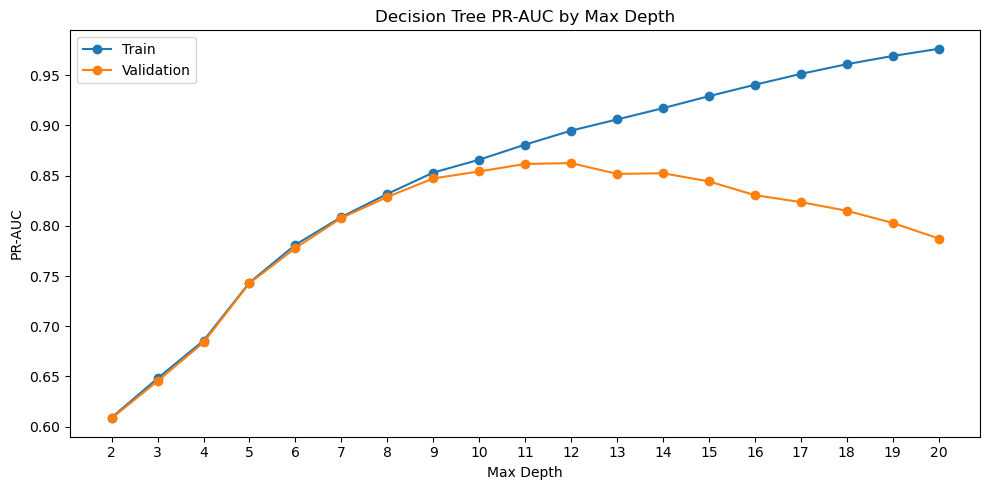

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(depths, train_pr_aucs, marker="o", label="Train")
plt.plot(depths, val_pr_aucs, marker="o", label="Validation")
plt.title("Decision Tree PR-AUC by Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("PR-AUC")
plt.xticks(list(depths))
plt.legend()
plt.tight_layout()
plt.show()

Validation peaks at depth 12 (0.8625) and falls off after, while train keeps climbing; the usual overfitting curve. Next we try `min_samples_leaf` at depth 12: forcing every leaf to hold a minimum number of bookings blocks the tiny noise-driven splits and should close some of the remaining train/val gap.

In [10]:
best_depth = 12
leaf_sizes = [1, 5, 10, 25, 50, 100]

for leaf_size in leaf_sizes:
    tree_model = DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                        max_depth=best_depth, min_samples_leaf=leaf_size,
                                        random_state=7)
    tree_model.fit(X_train_tree, Y_train_mini)
    train_roc, train_pr = pr_roc_scores(tree_model, X_train_tree, Y_train_mini)
    val_roc, val_pr = pr_roc_scores(tree_model, X_val_tree, Y_val)
    print("min_samples_leaf", leaf_size, "  train PR-AUC:", round(train_pr, 4),
          "  val PR-AUC:", round(val_pr, 4), "  gap:", round(train_pr - val_pr, 4))

min_samples_leaf 1   train PR-AUC: 0.8949   val PR-AUC: 0.8625   gap: 0.0324


min_samples_leaf 5   train PR-AUC: 0.8916   val PR-AUC: 0.8711   gap: 0.0206


min_samples_leaf 10   train PR-AUC: 0.8894   val PR-AUC: 0.8728   gap: 0.0166


min_samples_leaf 25   train PR-AUC: 0.8862   val PR-AUC: 0.8738   gap: 0.0124


min_samples_leaf 50   train PR-AUC: 0.882   val PR-AUC: 0.8727   gap: 0.0093


min_samples_leaf 100   train PR-AUC: 0.8761   val PR-AUC: 0.8673   gap: 0.0088


`min_samples_leaf=25` takes the best validation PR-AUC (0.8738) and cuts the train/val gap from 0.0324 to 0.0124. Bigger leaves keep shrinking the gap but start costing validation score, so we stop at 25.

## 7. Final Model Evaluation

Retrain the tuned tree (depth 12, `min_samples_leaf=25`) and score it on the held-out test set. All model selection happened on validation; test only confirms the pick.

In [11]:
final_tree = DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                    max_depth=12, min_samples_leaf=25, random_state=7)
final_tree.fit(X_train_tree, Y_train_mini)

train_roc, train_pr = pr_roc_scores(final_tree, X_train_tree, Y_train_mini)
val_roc, val_pr = pr_roc_scores(final_tree, X_val_tree, Y_val)
test_roc, test_pr = pr_roc_scores(final_tree, X_test_tree, Y_test)

print("Train ROC-AUC:", round(train_roc, 4), "  Train PR-AUC:", round(train_pr, 4))
print("Val ROC-AUC:", round(val_roc, 4), "  Val PR-AUC:", round(val_pr, 4))
print("Test ROC-AUC:", round(test_roc, 4), "  Test PR-AUC:", round(test_pr, 4))

Train ROC-AUC: 0.9249   Train PR-AUC: 0.8862
Val ROC-AUC: 0.9132   Val PR-AUC: 0.8738
Test ROC-AUC: 0.9121   Test PR-AUC: 0.8715


In [12]:
# Hard-label metrics at the default 0.5 cutoff
test_preds = final_tree.predict(X_test_tree)

print("Test accuracy:", round(accuracy_score(Y_test, test_preds), 4))
print("Test precision:", round(precision_score(Y_test, test_preds), 4))
print("Test recall:", round(recall_score(Y_test, test_preds), 4))
print("Test F1:", round(f1_score(Y_test, test_preds), 4))

Test accuracy: 0.8232
Test precision: 0.7367
Test recall: 0.814
Test F1: 0.7734


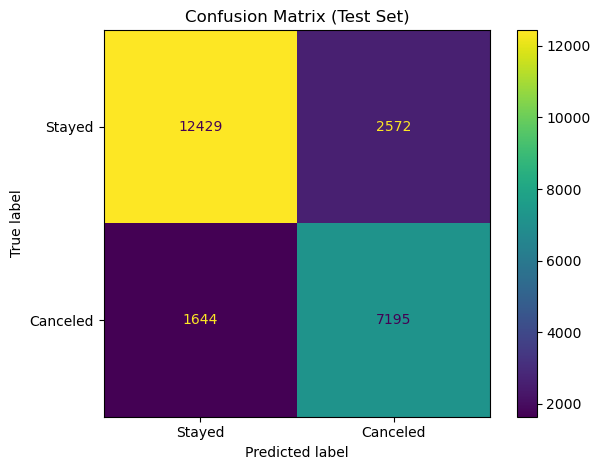

In [13]:
class_labels = final_tree.classes_
cm = confusion_matrix(Y_test, test_preds, labels=class_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Canceled"])
disp.plot()
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

Test lands at 0.9121 ROC-AUC and 0.8715 PR-AUC, basically on top of validation, so the tuning didn't overfit to the validation set. At the 0.5 cutoff we catch 81.4% of cancellations at 73.7% precision; the balanced class weights trade some false alarms for recall, and the cutoff itself is a business lever a hotel can move either direction.

## 8. Leakage Check

Same tuned configuration with `deposit_type_Non Refund` back in the feature set. If the column leaks outcome information, the scores should jump. Test shows up here again as a diagnostic only; nothing is being selected on it.

In [14]:
leaky_tree = DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                    max_depth=12, min_samples_leaf=25, random_state=7)
leaky_tree.fit(X_train_mini, Y_train_mini)

leaky_val_roc, leaky_val_pr = pr_roc_scores(leaky_tree, X_val, Y_val)
leaky_test_roc, leaky_test_pr = pr_roc_scores(leaky_tree, X_test, Y_test)

print("Without deposit col  val PR-AUC:", round(val_pr, 4), "  test PR-AUC:", round(test_pr, 4))
print("With deposit col     val PR-AUC:", round(leaky_val_pr, 4), "  test PR-AUC:", round(leaky_test_pr, 4))

Without deposit col  val PR-AUC: 0.8738   test PR-AUC: 0.8715
With deposit col     val PR-AUC: 0.8699   test PR-AUC: 0.8685


They don't: validation PR-AUC actually drops slightly with the column included (0.8699 vs 0.8738). The tree seems to recover the same signal through correlated features like country and channel, so we keep the suspect column out and lose nothing.

## 9. Feature Importance

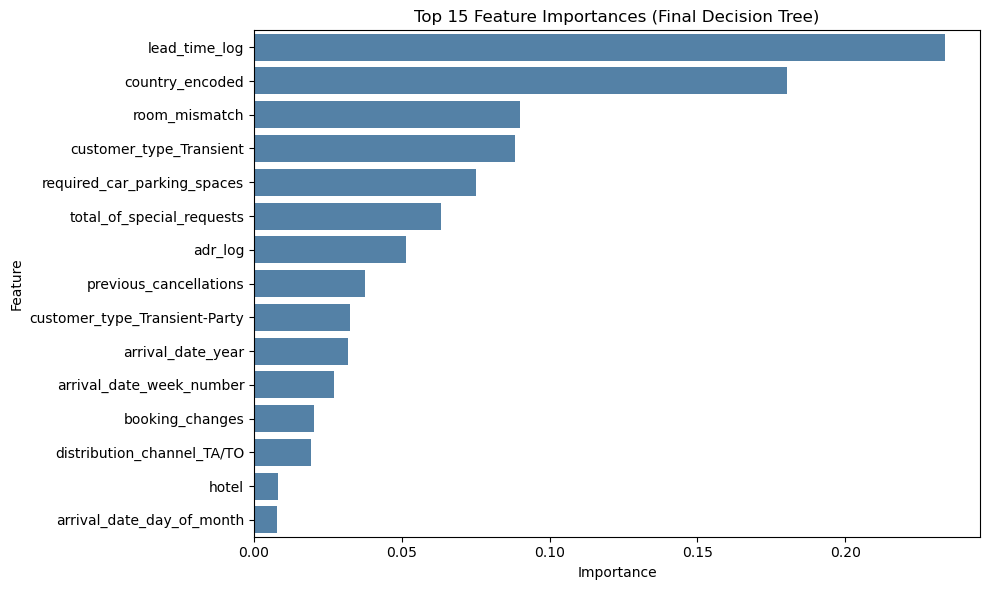

In [15]:
importances = pd.Series(final_tree.feature_importances_, index=X_train_tree.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances.values, y=top_importances.index, color="steelblue")
plt.title("Top 15 Feature Importances (Final Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The ranking matches the EDA story: `lead_time_log` (0.23) and `country_encoded` (0.18) lead by a wide margin, and the protective engagement signals (room mismatch, parking, special requests) all crack the top six. `adr_log` sitting mid-pack backs the mutual-information finding that price carries non-linear signal despite its weak linear correlation.

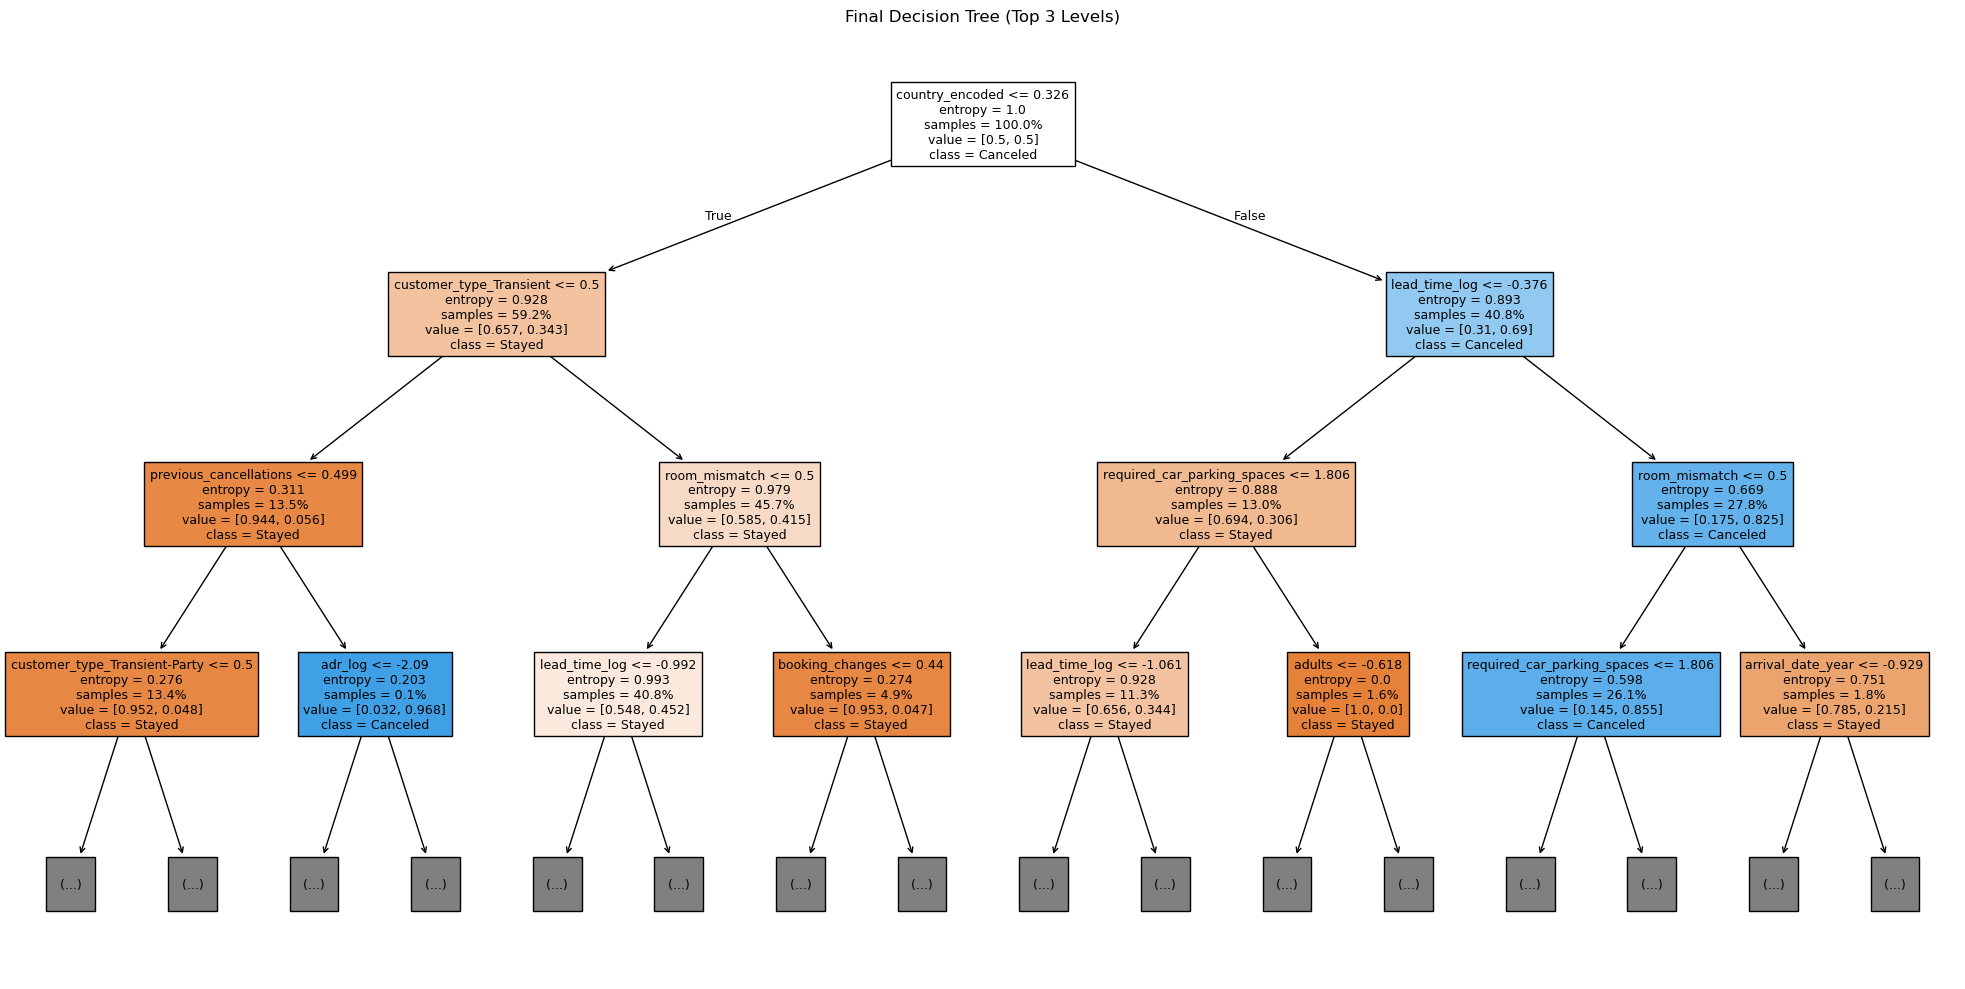

In [16]:
# Top 3 levels only; the full depth-12 tree is unreadable
plt.figure(figsize=(20, 10))
plot_tree(final_tree, max_depth=3, feature_names=X_train_tree.columns,
          class_names=["Stayed", "Canceled"], filled=True, proportion=True, fontsize=9)
plt.title("Final Decision Tree (Top 3 Levels)")
plt.tight_layout()
plt.show()

The top of the tree reads like the importance chart in action: the root split is country risk, and the next levels ask about customer type, lead time, previous cancellations, room mismatch, and parking. Split thresholds show up in standardized units because the features were scaled upstream; the tree doesn't care, but read them as relative values, not raw ones.

## 10. Summary

| Model | Val ROC-AUC | Val PR-AUC | Test ROC-AUC | Test PR-AUC |
|---|---|---|---|---|
| Majority baseline | 0.5 | 0.3708 | 0.5 | 0.3708 |
| Decision tree (depth 12, min_samples_leaf 25) | 0.9132 | 0.8738 | 0.9121 | 0.8715 |

The tree clears the baseline by a wide margin and holds up on test without the suspect deposit column. Still, a single tree makes a better benchmark than a final model; small changes in training data can reshuffle its splits, and the depth sweep showed how quickly it memorizes. We'd treat 0.87 test PR-AUC as the bar for random forest and XGBoost, which combine many trees to fix exactly that weakness.